Instacart: https://www.instacart.com/
Base de datos: +3Millones ordenes, Usuarios, Productos, Pasillos
Analisis: Basket Analysis
Es un análisis matemático para encontrar patrones en la información de los tickets de venta de un conjunto de tiendas, durante un periodo determinado.

Adicionando Librerias para el EDA

In [1]:
import numpy as np
import pandas as pd
import os
import zipfile
import glob
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import datetime
from IPython.display import display
import random

# definiendo paleta de colores a usar para mantener visualizaciones uniformes
# colors = sns.color_palette("hls", 8)
colors = sns.color_palette("crest", 8)
cmap_colors = sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True)

# definiendo el tamaño para todas las graficas a generar
plt.rcParams["figure.figsize"] = (10,6)
# Ubicacion de la data
data_directory_path = './Data/'

# Conversion de los dias de la semana de numero a texto
days_of_week = {0: 'Saturday', 
                1: 'Sunday', 
                2: 'Monday',
                3: 'Tuesday',
                4: 'Wednesday',
                5: 'Thursday',
                6: 'Friday'}
hour_nums = list(range(24))
hours_of_day = {hour_num:datetime.time(hour_num).strftime("%I:00 %p") for hour_num in hour_nums}

In [2]:
# Descomprimiendo archivos de transacciones, clientes, productos, pasillos

for dirname, _, filenames in os.walk('/data'):
    for filename in filenames:
        with zipfile.ZipFile(os.path.join(dirname, filename), 'r') as zip_ref:
            zip_ref.extractall(data_directory_path)

In [3]:
''' 
    Asignando los tipos de datos adecuados para reducir tamaño del dataset
'''
def reduce_mem_usage(train_data):
    start_mem = train_data.memory_usage().sum() / 1024**2
    print('Uso de memoria del dataframe= {:.2f} MB'.format(start_mem))

    for col in train_data.columns:
        col_type = train_data[col].dtype
        
        if col_type not in [object, 'category']:
            c_min = train_data[col].min()
            c_max = train_data[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    train_data[col] = train_data[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    train_data[col] = train_data[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    train_data[col] = train_data[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    train_data[col] = train_data[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    train_data[col] = train_data[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    train_data[col] = train_data[col].astype(np.float32)
                else:
                    train_data[col] = train_data[col].astype(np.float64)
        else:
            train_data[col] = train_data[col].astype('category')
    end_mem = train_data.memory_usage().sum() / 1024**2
    print('Tamaño optimizado: {:.2f} MB'.format(end_mem))
    print('% reduccion {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return train_data

# Annotate text on graph
def annotate_text(p, append_to_text='%'):
    for p in ax.patches:
        txt = str(p.get_height().round(2)) + append_to_text
        txt_x = p.get_x() + p.get_width()/2.
        txt_y = 0.92*p.get_height()
        ax.text(txt_x,txt_y,txt, fontsize=20, color='#004235', ha='center', va='bottom')

## Leyendo la data

In [6]:

aisles = pd.read_csv(data_directory_path + 'aisles.csv')
aisles = reduce_mem_usage(aisles)

departments = pd.read_csv(data_directory_path + 'departments.csv')
departments = reduce_mem_usage(departments)

order_products_prior = pd.read_csv(data_directory_path + 'order_products__prior.csv')
order_products_prior = reduce_mem_usage(order_products_prior)

order_products_train = pd.read_csv(data_directory_path + 'order_products__train.csv')
order_products_train = reduce_mem_usage(order_products_train)

orders = pd.read_csv(data_directory_path + 'orders.csv')
# Estandarizando la hora del dia para cada transaccion
orders['order_hour_of_day'] = orders['order_hour_of_day'].replace(to_replace=hours_of_day)
orders['order_hour_of_day'] = pd.Categorical(orders['order_hour_of_day'], 
                                             ordered=True, 
                                             categories=list(hours_of_day.values()))
# Estandarizando los dias de la semana de numero a descriptivo
orders['order_dow'] = orders['order_dow'].replace(to_replace=days_of_week)
orders['order_dow'] = pd.Categorical(orders['order_dow'], 
                                     ordered=True, 
                                     categories=list(days_of_week.values()))
orders = reduce_mem_usage(orders)

products = pd.read_csv(data_directory_path + 'products.csv')
products = reduce_mem_usage(products)

Uso de memoria del dataframe= 0.00 MB
Tamaño optimizado: 0.01 MB
% reduccion -159.9%
Uso de memoria del dataframe= 0.00 MB
Tamaño optimizado: 0.00 MB
% reduccion -92.7%
Uso de memoria del dataframe= 989.82 MB
Tamaño optimizado: 340.25 MB
% reduccion 65.6%
Uso de memoria del dataframe= 42.26 MB
Tamaño optimizado: 13.20 MB
% reduccion 68.7%
Uso de memoria del dataframe= 137.03 MB
Tamaño optimizado: 45.68 MB
% reduccion 66.7%
Uso de memoria del dataframe= 1.52 MB
Tamaño optimizado: 1.91 MB
% reduccion -25.8%


## Analizando la Data

In [7]:
print('Shape of order_products_train table: ', order_products_train.shape)
order_products_train.head(10)

Shape of order_products_train table:  (1384617, 4)


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1
5,1,13176,6,0
6,1,47209,7,0
7,1,22035,8,1
8,36,39612,1,0
9,36,19660,2,1


In [8]:
print('Shape of order_products_prior table: ', order_products_prior.shape)
order_products_prior.head(10)

Shape of order_products_prior table:  (32434489, 4)


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0
5,2,17794,6,1
6,2,40141,7,1
7,2,1819,8,1
8,2,43668,9,0
9,3,33754,1,1


In [9]:
print('Shape of products table: ', products.shape)
print('Uniques products', products['product_name'].nunique())
products.head(20)

Shape of products table:  (49688, 4)
Uniques products 49688


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
5,6,Dry Nose Oil,11,11
6,7,Pure Coconut Water With Orange,98,7
7,8,Cut Russet Potatoes Steam N' Mash,116,1
8,9,Light Strawberry Blueberry Yogurt,120,16
9,10,Sparkling Orange Juice & Prickly Pear Beverage,115,7


In [10]:
organic = products['product_name'].str.contains('Organic')
products['is_organic'] = organic

In [11]:
print('Shape of departments table: ', departments.shape)
departments.head(departments.shape[0])

Shape of departments table:  (21, 2)


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol
5,6,international
6,7,beverages
7,8,pets
8,9,dry goods pasta
9,10,bulk


In [12]:
print('Shape of aisles table: ', aisles.shape)
aisles.head(10)

Shape of aisles table:  (134, 2)


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation
5,6,other
6,7,packaged meat
7,8,bakery desserts
8,9,pasta sauce
9,10,kitchen supplies


In [13]:
print('Shape of Orders table: ', orders.shape)
orders.head(12)

Shape of Orders table:  (3421083, 7)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,Monday,08:00 AM,NaN
1,2398795,1,prior,2,Tuesday,07:00 AM,15.0
2,473747,1,prior,3,Tuesday,12:00 PM,21.0
3,2254736,1,prior,4,Wednesday,07:00 AM,29.0
4,431534,1,prior,5,Wednesday,03:00 PM,28.0
5,3367565,1,prior,6,Monday,07:00 AM,19.0
6,550135,1,prior,7,Sunday,09:00 AM,20.0
7,3108588,1,prior,8,Sunday,02:00 PM,14.0
8,2295261,1,prior,9,Sunday,04:00 PM,0.0
9,2550362,1,prior,10,Wednesday,08:00 AM,30.0


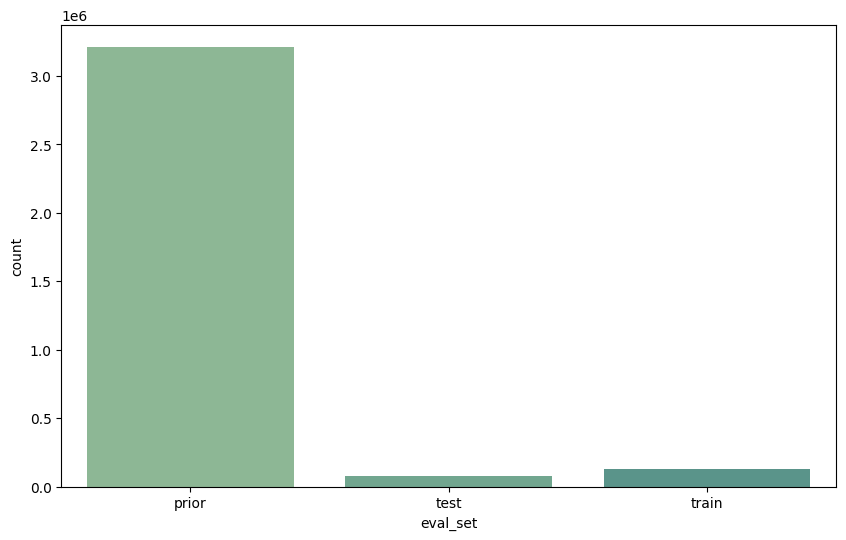

In [20]:
sns.countplot(x='eval_set', hue='eval_set', data=orders, palette=colors[:3],  legend=False)
plt.show()

In [21]:
# Merging the Prior and train order_products
order_products = pd.concat([order_products_train, order_products_prior])
order_products = order_products.merge(products, on='product_id', how='left').merge(orders, on='order_id', how='left').merge(departments, on='department_id').merge(aisles, on='aisle_id')

# Count of total orders
total_orders = order_products['order_id'].nunique()
print('Count of total orders: ', total_orders)

print('Merging products, order_products, and orders tables...')

order_products.head()

Count of total orders:  3346083
Merging products, order_products, and orders tables...


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,is_organic,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,department,aisle
0,1,49302,1,1,Bulgarian Yogurt,120,16,False,112108,train,4,Wednesday,10:00 AM,9.0,dairy eggs,yogurt
1,1,11109,2,1,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,True,112108,train,4,Wednesday,10:00 AM,9.0,dairy eggs,other creams cheeses
2,1,10246,3,0,Organic Celery Hearts,83,4,True,112108,train,4,Wednesday,10:00 AM,9.0,produce,fresh vegetables
3,1,49683,4,0,Cucumber Kirby,83,4,False,112108,train,4,Wednesday,10:00 AM,9.0,produce,fresh vegetables
4,1,43633,5,1,Lightly Smoked Sardines in Olive Oil,95,15,False,112108,train,4,Wednesday,10:00 AM,9.0,canned goods,canned meat seafood


### Ratios
- se reordeno el 58.9% de los productos en pedidos anteriores.
- el 41% de las ordenes contenian productos que los estaban pidiendo por primera vez


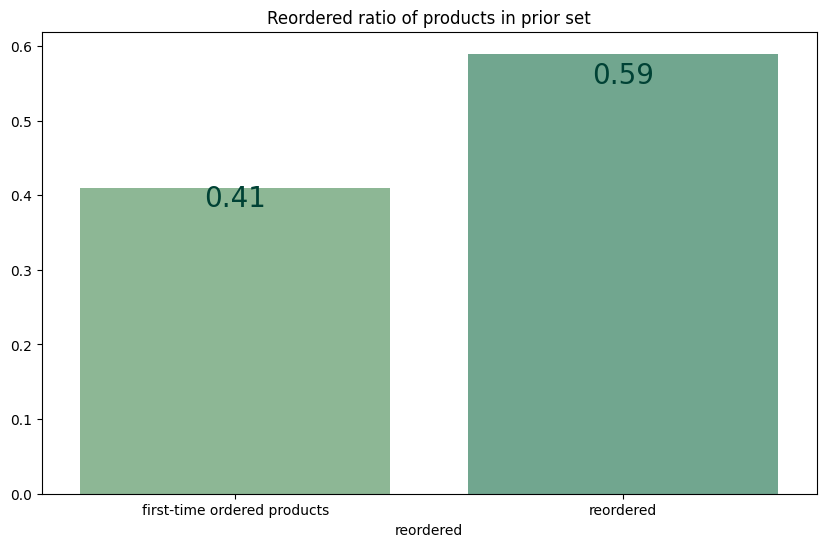

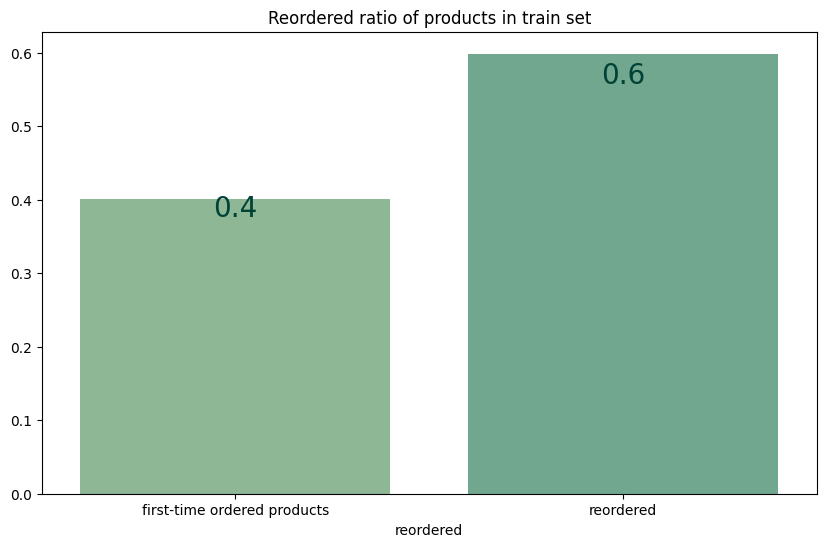

In [22]:
total_prod_count = order_products_prior.shape[0]
reorder_ratio = order_products_prior['reordered'].value_counts()/total_prod_count

ax = sns.barplot(
    x=reorder_ratio.index, 
    y=reorder_ratio.values, 
    hue=reorder_ratio.index, 
    palette=colors[:2], 
    legend=False
)
ax.set_xticks([0, 1])
ax.set_xticklabels(['first-time ordered products', 'reordered'])
annotate_text(ax, append_to_text='')
plt.title('Reordered ratio of products in prior set')
plt.show()


total_prod_count = order_products_train.shape[0]
reorder_ratio = order_products_train['reordered'].value_counts() / total_prod_count

ax = sns.barplot(
    x=reorder_ratio.index, 
    y=reorder_ratio.values, 
    hue=reorder_ratio.index, 
    palette=colors[:2], 
    legend=False
)
ax.set_xticks([0, 1])
ax.set_xticklabels(['first-time ordered products', 'reordered'])
annotate_text(ax, append_to_text='')
plt.title('Reordered ratio of products in train set')
plt.show()

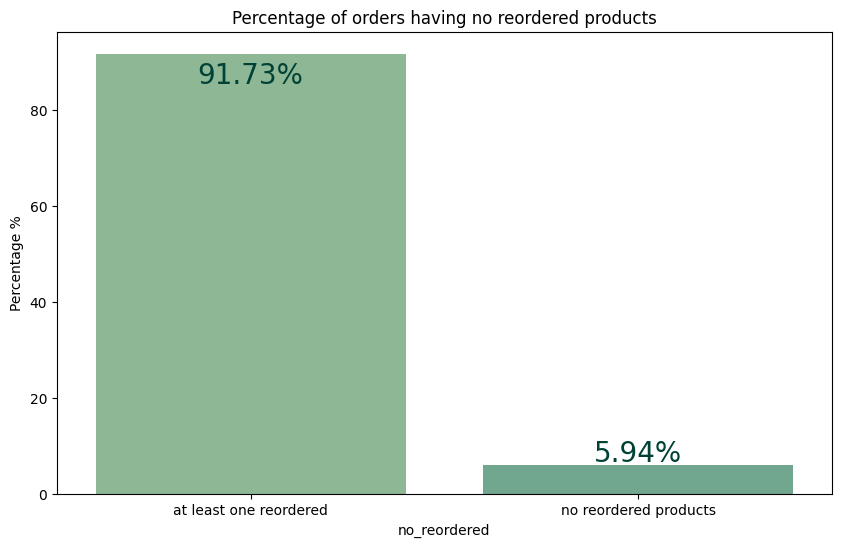

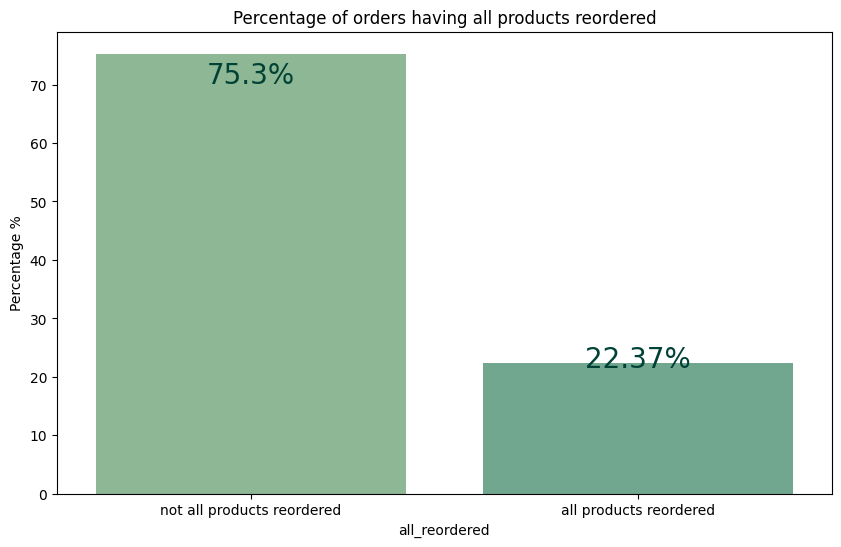

,order_id,reordered_ratio,order_number,no_reordered,all_reordered
0,1,0.500000,4,False,False
1,2,0.666667,3,False,False
2,3,1.000000,16,False,True
3,4,0.923077,36,False,False
4,5,0.807692,42,False,False


In [24]:
groupeddf = order_products.groupby(['order_id']).agg({'reordered':'mean', 'order_number':'first'}).reset_index().rename(columns={'reordered':'reordered_ratio'})
groupeddf['no_reordered'] = groupeddf['reordered_ratio'] == 0
groupeddf['all_reordered'] = groupeddf['reordered_ratio'] == 1.0

# Count of non-first orders
non_first_orders_Mask = orders.order_number != 1
non_first_orders_count = np.sum(non_first_orders_Mask)

# Ratio of non-first orders containing no previously ordered products vs containing at least one previously ordered products
groupeddf = groupeddf[groupeddf.order_number != 1]
groupeddf['no_reordered'] = groupeddf['reordered_ratio'] == 0
no_reordered_count = groupeddf['no_reordered'].value_counts()/non_first_orders_count * 100
ax = sns.barplot(
    x=no_reordered_count.index, 
    y=no_reordered_count.values, 
    hue=no_reordered_count.index, 
    palette=colors[:2], 
    legend=False
)
ax.set_xticks([0, 1])
ax.set_xticklabels(['at least one reordered', 'no reordered products'])
annotate_text(ax)
plt.title('Percentage of orders having no reordered products')
plt.ylabel('Percentage %')
plt.show()

# Ratio of non-first orders where their products were all previously purchased
groupeddf['all_reordered'] = groupeddf['reordered_ratio'] == 1.0
all_reordered_count = groupeddf['all_reordered'].value_counts()/non_first_orders_count * 100
ax = sns.barplot(
    x=all_reordered_count.index, 
    y=all_reordered_count.values, 
    hue=all_reordered_count.index, 
    palette=colors[:2], 
    legend=False
)
ax.set_xticks([0, 1])
ax.set_xticklabels(['not all products reordered', 'all products reordered'])
annotate_text(ax)
plt.title('Percentage of orders having all products reordered')
plt.ylabel('Percentage %')
plt.show()

groupeddf.head()

- La mayoria de las canastas llevan de 5 a 8 productos.
- Los productos que se agregan primero son los mas reordenados.

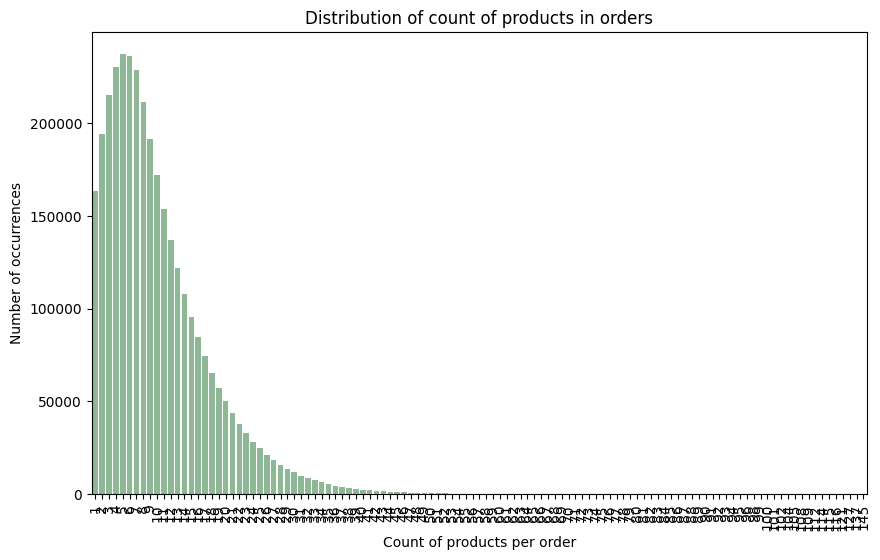

In [27]:
# Calcular el número de productos por orden
count_of_products = order_products.groupby('order_id')['product_id'].count().reset_index(name='count_of_products')

# Graficar usando countplot, sin usar hue ni una paleta compleja
sns.countplot(x='count_of_products', data=count_of_products, color=colors[0])

# Etiquetas y título
plt.xlabel('Count of products per order')
plt.ylabel('Number of occurrences')
plt.title('Distribution of count of products in orders')

# Rotar etiquetas del eje X para legibilidad
plt.xticks(rotation=90)

# Mostrar el gráfico
plt.show()

# Liberar memoria
del count_of_products


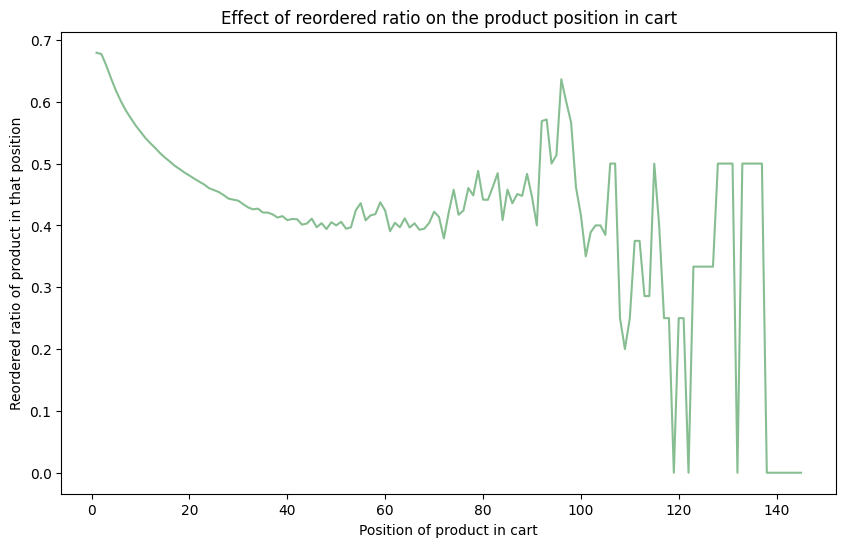

In [29]:
# Relation between the order number and the reorder ratio of that order

# Relation between the add to cart postiion and the reorder ratio of that product
groupeddf = order_products.groupby(['add_to_cart_order']).agg({'reordered':'mean'}).rename(columns={'reordered':'reordered_ratio'}).reset_index()
sns.lineplot(x='add_to_cart_order', y='reordered_ratio', data=groupeddf, color=colors[0])
plt.title('Effect of reordered ratio on the product position in cart')
plt.xlabel('Position of product in cart')
plt.ylabel('Reordered ratio of product in that position')
plt.show()

### Resumen de productos reordenados
- Most baskets have from 0-5 reordered product
- Probabilidad de que en la canasta ningun producto este reordenado: 11.868056
- Probabilidad de que la canasta contenga 1 producto reordenado: 10.262626
- Probabilidad de que la canasta contenga 2 productos reordenados: 10.326791
- Probabilidad de que la canasta contenga 3 productos reordenados: 9.735981
- Probabilidad de que la canasta contenga 4 productos reordenados: 8.777965

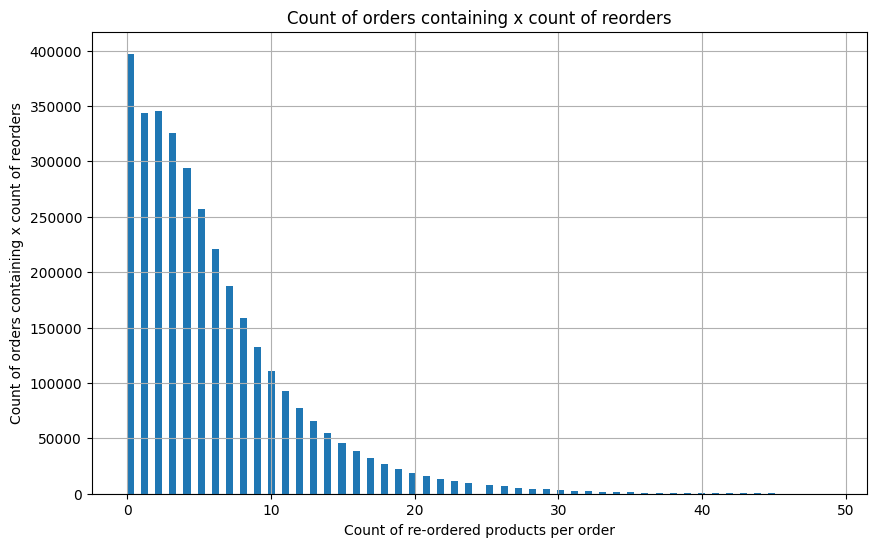

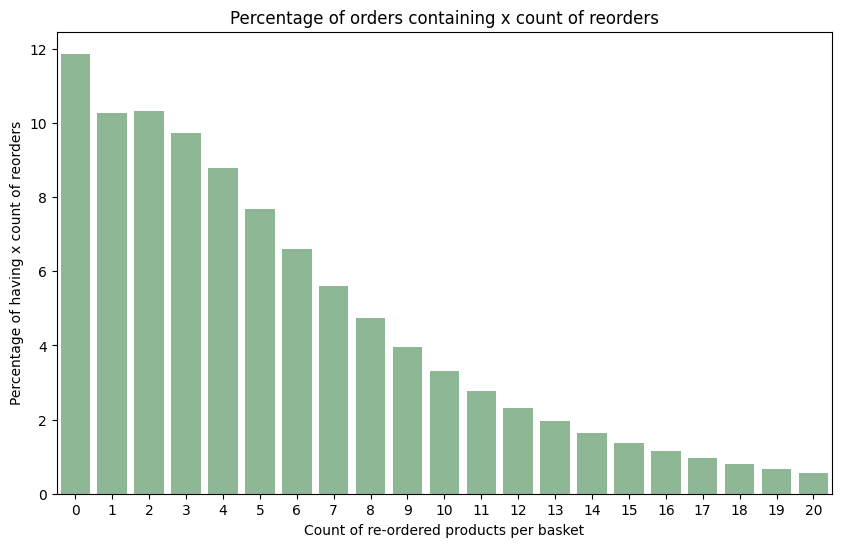

In [31]:
# Ploting a histogram for the # of reordered products in an order
count_of_reordered_products = order_products.groupby(['order_id'], as_index=False)['reordered'].sum()
count_of_reordered_products['count_of_reordered_products'] = count_of_reordered_products['reordered']
less_than_50_reordered_products = count_of_reordered_products[count_of_reordered_products['count_of_reordered_products']<50]
less_than_50_reordered_products['count_of_reordered_products'].hist(bins=100)
plt.ylabel('Count of orders containing x count of reorders')
plt.xlabel('Count of re-ordered products per order')
plt.title('Count of orders containing x count of reorders')

plt.show()

# Percentage of orders having x count_of_reordered_products
reordered_products_count_histogram = count_of_reordered_products.groupby(['count_of_reordered_products'], as_index=False).count()
reordered_products_count_histogram['count_of_orders'] = reordered_products_count_histogram['reordered']
reordered_products_count_histogram['percentage_of_this_reordered_count'] = (reordered_products_count_histogram['count_of_orders']/total_orders) * 100
reordered_products_count_histogram = reordered_products_count_histogram[['count_of_reordered_products','count_of_orders','percentage_of_this_reordered_count']]
# Filtrar reorders con porcentaje significativo
mask = reordered_products_count_histogram['percentage_of_this_reordered_count'] > 0.5
reordered_products_count_histogram = reordered_products_count_histogram[mask].sort_values(
    by='percentage_of_this_reordered_count', ascending=False
)

# Graficar sin warnings
sns.barplot(
    x='count_of_reordered_products',
    y='percentage_of_this_reordered_count',
    data=reordered_products_count_histogram,
    color=colors[0]
)
plt.ylabel('Percentage of having x count of reorders')
plt.xlabel('Count of re-ordered products per basket')
plt.title('Percentage of orders containing x count of reorders')
plt.show()


###Comportamiento de los Usuarios

In [32]:
# Getting list of user ids, who always reorder products from their first order.
non_first_orders_mask = order_products['order_number'] != 1
groupeddf = order_products[non_first_orders_mask].groupby(['user_id']).agg({'reordered':'mean', 'order_number':'count'}).rename(columns={'reordered':'reordered_ratio'})
mask = groupeddf['reordered_ratio'] == 1
always_reorder_users_id = groupeddf[mask].index.to_list()
print('Count of users who always order the same products every time:', len(always_reorder_users_id))

# getting the orders of the a random user
rand_indx = random.randint(0,len(always_reorder_users_id))
rand_user_id = always_reorder_users_id[rand_indx]
user_mask = orders['user_id'] == rand_user_id
user_orders = orders[user_mask]['order_id'].to_list()
print('Orders of one of these users:')
for order_id in user_orders:
    print('order products')
    print(order_products[order_products['order_id'] == order_id]['product_name'].to_list())
    print('--------------')

Count of users who always order the same products every time: 685
Orders of one of these users:
order products
['Hass Avocados']
--------------
order products
['Hass Avocados']
--------------
order products
['Hass Avocados']
--------------
order products
[]
--------------


- La mayoria de ordenes se dan en sabado y domingo
- La mayoria de ordenes se recibe de 9 a 4pm
- Sabados a la 1pm y domingo a las 10am son las horas pico
- Existe alta probabilidad de que el cliente vuelva a ordenar dentro de 10 días a partir de su orden actual

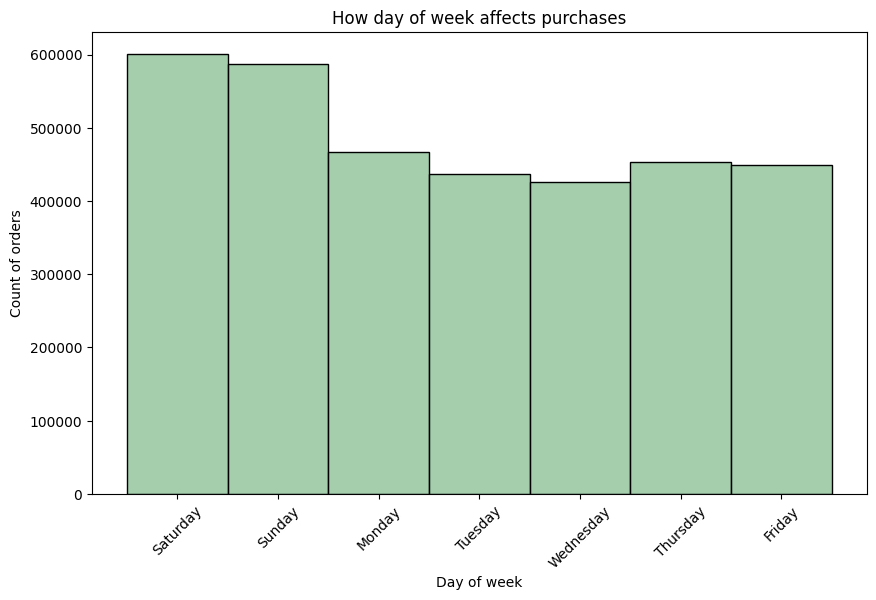

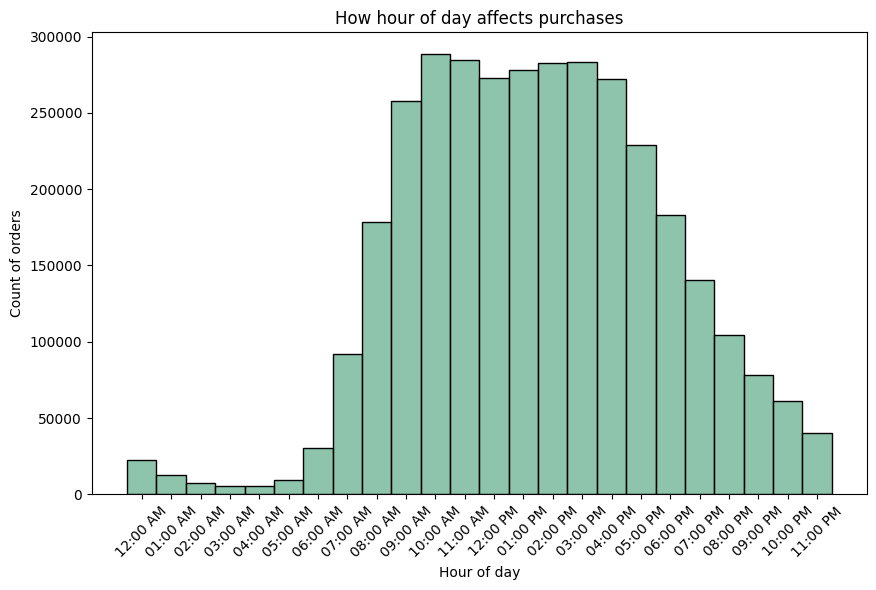

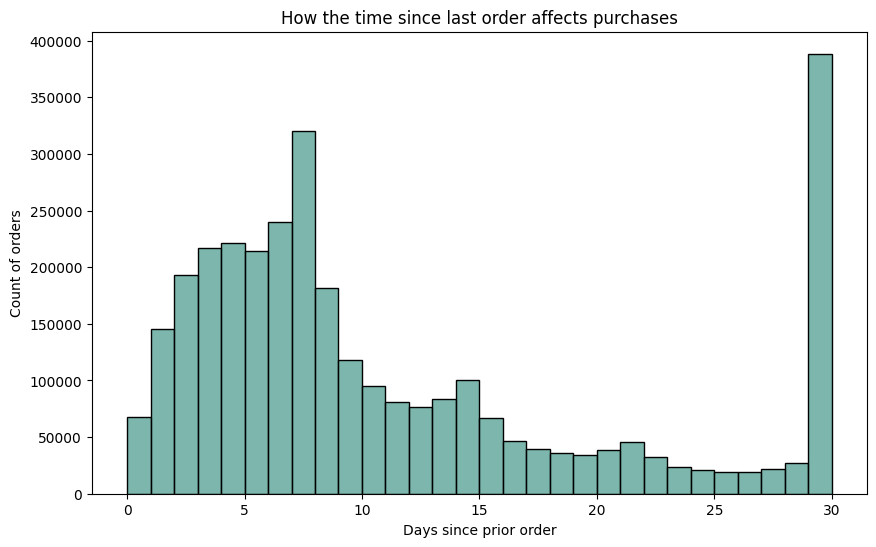

In [35]:
# Histogram for order day of week
sns.histplot(data=orders, x='order_dow', bins=7, color=colors[0])
plt.xlabel('Day of week')
plt.ylabel('Count of orders')
plt.title('How day of week affects purchases')
plt.xticks(rotation=45)
plt.show()

# Histogram for order hour of day
sns.histplot(data=orders, x='order_hour_of_day', bins=24, color=colors[1])
plt.xlabel('Hour of day')
plt.ylabel('Count of orders')
plt.title('How hour of day affects purchases')
plt.xticks(rotation=45)
plt.show()

# Histogram for days passed before last order
sns.histplot(data=orders, x='days_since_prior_order', bins=30, color=colors[2])
plt.xlabel('Days since prior order')
plt.ylabel('Count of orders')
plt.title('How the time since last order affects purchases')
plt.show()

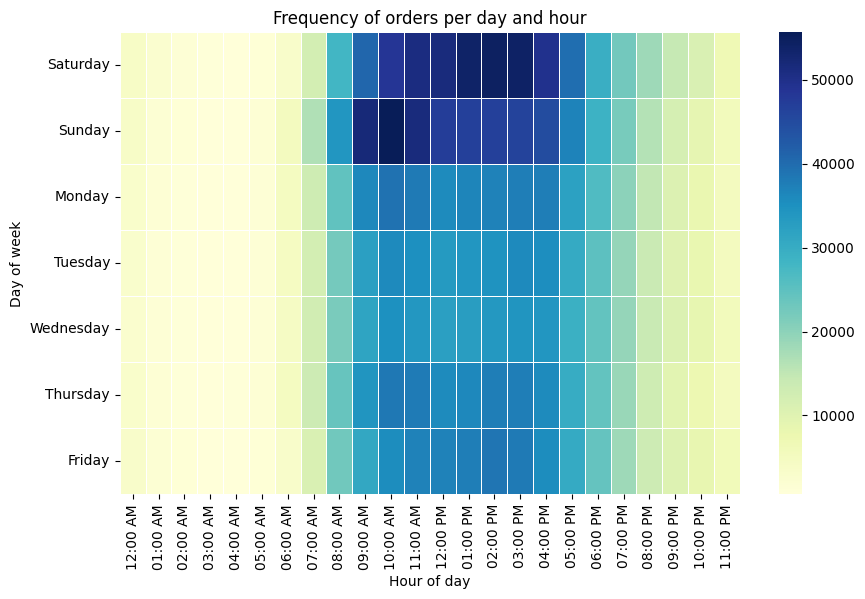

In [37]:
# Agrupamos por día de la semana y hora del día
groupeddf = orders.groupby(['order_dow', 'order_hour_of_day'], observed=True)['order_id'].count().reset_index().rename(columns={'order_id': 'orders_count'})

# Pivot para preparar datos para heatmap
heatmap_data = groupeddf.pivot(index='order_dow', columns='order_hour_of_day', values='orders_count')

# Dibujar heatmap
ax = sns.heatmap(data=heatmap_data, cmap="YlGnBu", linewidths=0.5)
plt.title('Frequency of orders per day and hour')
plt.ylabel('Day of week')
plt.xlabel('Hour of day')
plt.show()


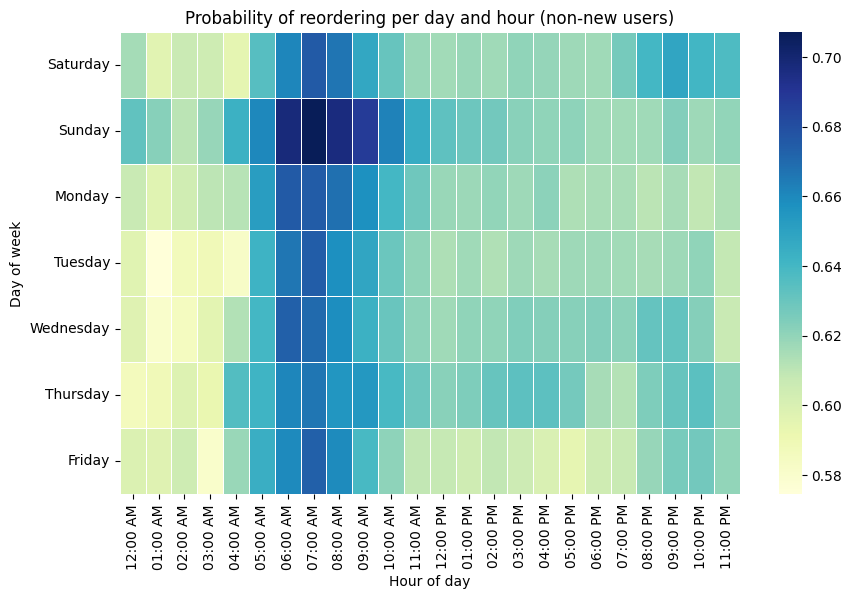

In [39]:
# Filtrar órdenes que no son la primera
non_first_orders = order_products['order_number'] != 1

# Calcular ratio de reorders por día y hora
groupeddf = order_products[non_first_orders].groupby(
    ['order_dow', 'order_hour_of_day'],
    observed=True
)['reordered'].mean().reset_index().rename(columns={'reordered': 'reordered_ratio'})

# Pivot para el heatmap
heatmap_data = groupeddf.pivot(
    index='order_dow',
    columns='order_hour_of_day',
    values='reordered_ratio'
)

# Dibujar el heatmap
ax = sns.heatmap(data=heatmap_data, cmap="YlGnBu", linewidths=0.5)
plt.title('Probability of reordering per day and hour (non-new users)')
plt.ylabel('Day of week')
plt.xlabel('Hour of day')
plt.show()


### Association between days since last order and the ratio of reorders
- 74 % of products bought at the same day of prev order, are reorders
- 69% of products bought after 1 week of prev order, are reorders
- Conculsion:
    - if future order will be at the same day of prev order, percentage of reorders in the future product is high.
    - if future order will be after a week from the prev order, percentage of reorders in the future product is high.


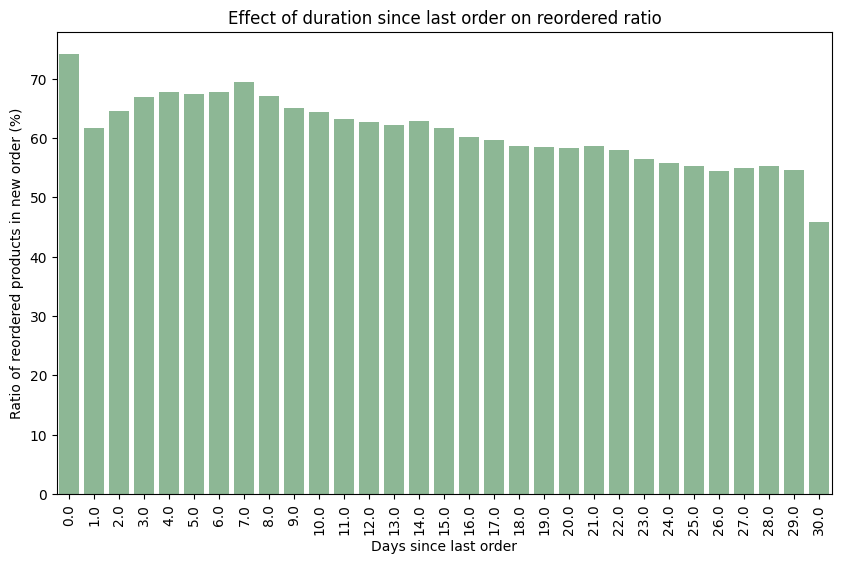

In [41]:
# Asegurar que la columna no sea float16 (que no es soportada en index)
order_products['days_since_prior_order'] = order_products['days_since_prior_order'].astype('float32')

# Agrupar y calcular la media de reorders por días desde el pedido anterior
groupeddf = order_products.groupby('days_since_prior_order')['reordered'].mean().reset_index()
groupeddf.rename(columns={'reordered': 'reordered_ratio'}, inplace=True)

# Graficar
sns.barplot(
    x='days_since_prior_order',
    y=groupeddf['reordered_ratio'] * 100,
    data=groupeddf,
    color=colors[0]
)
plt.ylabel('Ratio of reordered products in new order (%)')
plt.xlabel('Days since last order')
plt.xticks(rotation=90)
plt.title('Effect of duration since last order on reordered ratio')
plt.show()



- 5 Productos mas ordenados
    - Banana
    - Bag of Organic Bananas
    - Organic Strawberries
    - Organic Baby Spinach
    - Organic Hass Avocado
- 14% de todas las ordenes contienen bananas
- Los productos organicos tienen una frecuencia alta de aparición.

Productos con Ratios de reorden mas altos

C:\Users\Admin\AppData\Local\Temp\ipykernel_29656\2851222551.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupeddf = order_products[non_first_orders_Mask].groupby('product_name').agg({'order_id':'count','reordered':'mean'}).reset_index().rename(columns={'reordered':'reordered_ratio', 'order_id':'orders_count'})


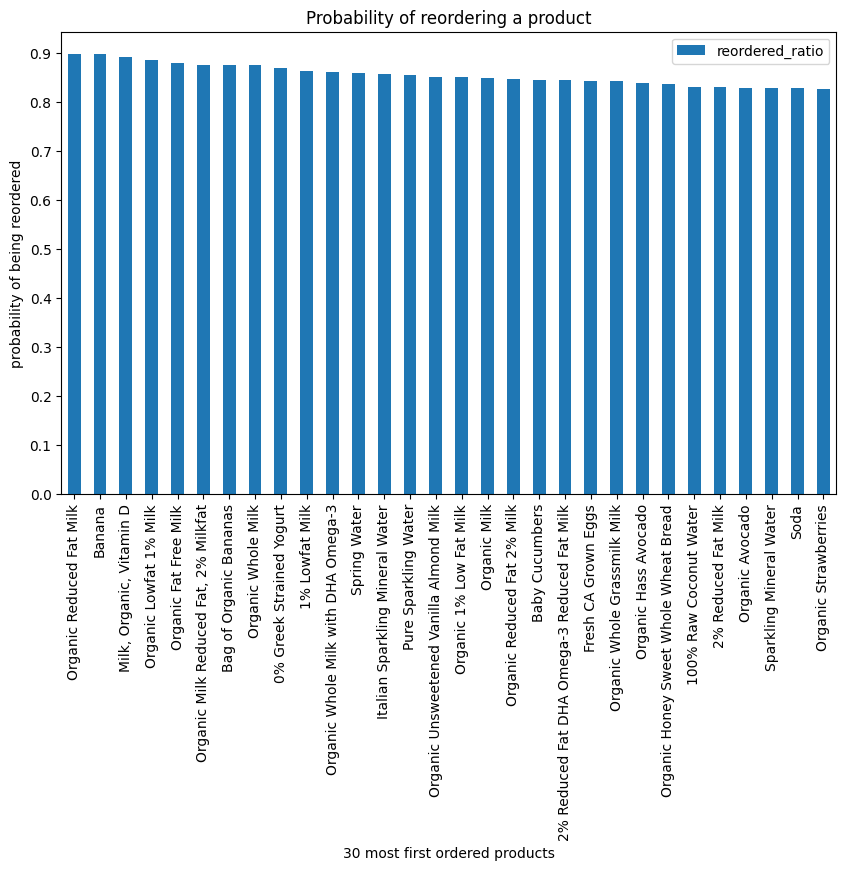

In [48]:
# For each product what is its probability to be reordered.
# We don't consider the first order of the user because 100% it won't contain any prev. ordered products.
non_first_orders_Mask = order_products['order_number'] != 1
groupeddf = order_products[non_first_orders_Mask].groupby('product_name').agg({'order_id':'count','reordered':'mean'}).reset_index().rename(columns={'reordered':'reordered_ratio', 'order_id':'orders_count'})

# Filter products under 10000 order count
groupeddf = groupeddf[groupeddf['orders_count']>10000]
# Sort by the products having highest prob to be reordered
groupeddf = groupeddf.sort_values(by=['reordered_ratio'], ascending=False)

ax = groupeddf.iloc[:30].plot.bar(x='product_name', y='reordered_ratio')
plt.xlabel('30 most first ordered products')
plt.ylabel('probability of being reordered')
plt.xticks(rotation=90)
plt.title('Probability of reordering a product')
ax.set_yticks(np.arange(0.0, 1.0, 0.1))
plt.show()

del non_first_orders_Mask

Analizando los productos organicos

C:\Users\Admin\AppData\Local\Temp\ipykernel_29656\482649455.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x= organic_ratio.index, y=organic_ratio.values, palette=colors)
C:\Users\Admin\AppData\Local\Temp\ipykernel_29656\482649455.py:4: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  ax = sns.barplot(x= organic_ratio.index, y=organic_ratio.values, palette=colors)


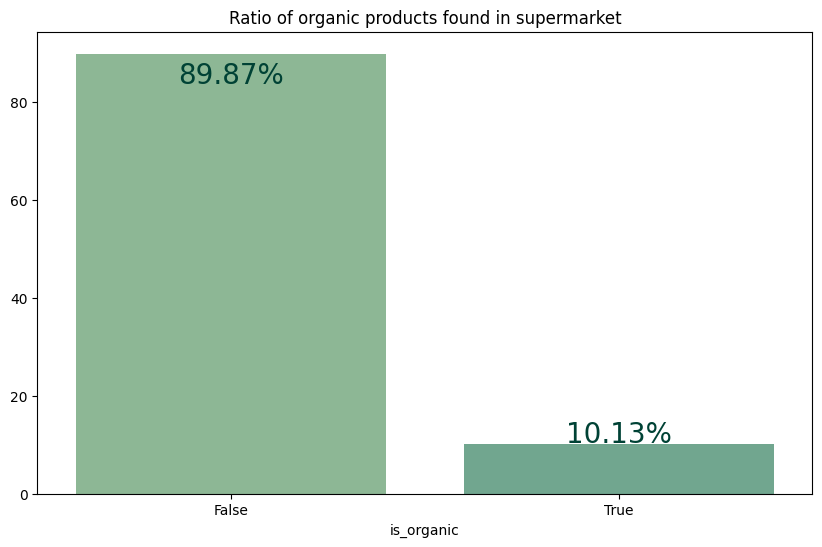

In [49]:
# Ratio of organic products found in supermarket
total_products_count = products.shape[0]
organic_ratio = products['is_organic'].value_counts()/total_products_count*100
ax = sns.barplot(x= organic_ratio.index, y=organic_ratio.values, palette=colors)
annotate_text(ax)
plt.title('Ratio of organic products found in supermarket')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_29656\1141663855.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x= organic_freq.index, y=organic_freq.values, palette=colors)
C:\Users\Admin\AppData\Local\Temp\ipykernel_29656\1141663855.py:4: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  ax = sns.barplot(x= organic_freq.index, y=organic_freq.values, palette=colors)
C:\Users\Admin\AppData\Local\Temp\ipykernel_29656\1141663855.py:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['non-organic', 'organic'])


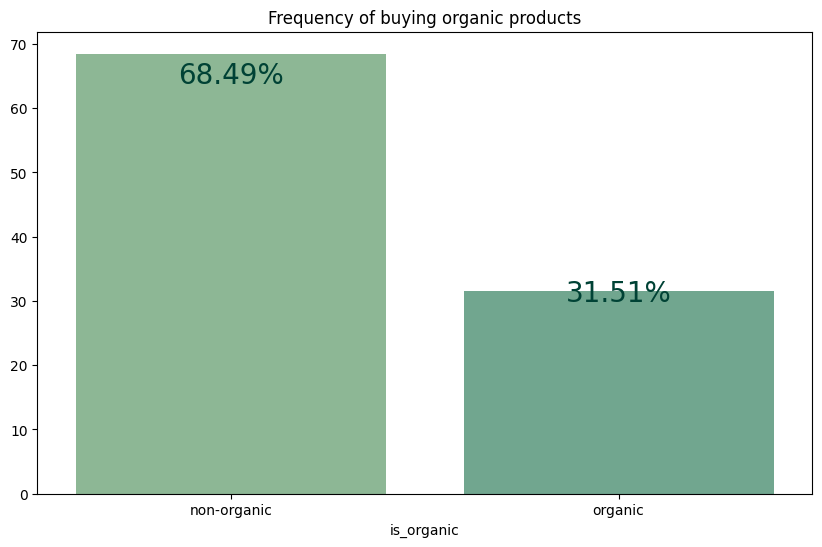

In [50]:
# Frequency of buying organic products
total_order_products_count = order_products.shape[0]
organic_freq = order_products['is_organic'].value_counts()/total_order_products_count*100
ax = sns.barplot(x= organic_freq.index, y=organic_freq.values, palette=colors)
ax.set_xticklabels(['non-organic', 'organic'])
annotate_text(ax)
plt.title('Frequency of buying organic products')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_29656\1918901174.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='is_organic', y='reordered_ratio', data=groupeddf, palette=colors)
C:\Users\Admin\AppData\Local\Temp\ipykernel_29656\1918901174.py:4: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  ax = sns.barplot(x='is_organic', y='reordered_ratio', data=groupeddf, palette=colors)
C:\Users\Admin\AppData\Local\Temp\ipykernel_29656\1918901174.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['non-organic', 'organic'])


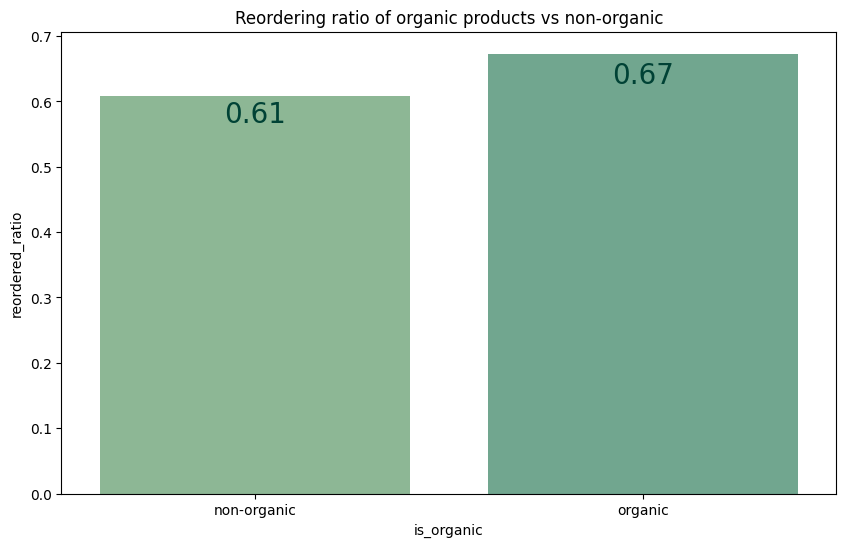

In [51]:
# Reordering ratio of organic products vs non-organic
non_first_orders_mask = order_products['order_number'] != 1
groupeddf = order_products[non_first_orders_mask].groupby(['is_organic']).agg({'reordered':'mean'}).rename(columns={'reordered':'reordered_ratio'}).reset_index()
ax = sns.barplot(x='is_organic', y='reordered_ratio', data=groupeddf, palette=colors)
annotate_text(ax, append_to_text='')
ax.set_xticklabels(['non-organic', 'organic'])
plt.title('Reordering ratio of organic products vs non-organic')
plt.show()

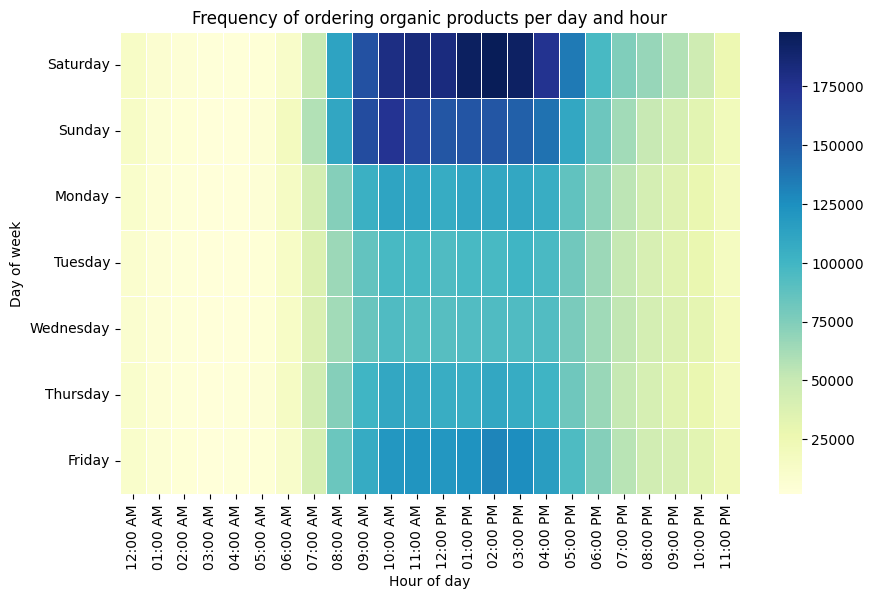

In [53]:
# Agrupación explícita con observed=True para evitar warning
groupeddf = order_products.groupby(
    ['order_dow', 'order_hour_of_day'],
    observed=True
)['is_organic'].sum().reset_index().rename(columns={'is_organic': 'organic_products_count'})

# Pivot para construir el heatmap
heatmap_data = groupeddf.pivot(
    index='order_dow',
    columns='order_hour_of_day',
    values='organic_products_count'
)

# Graficar el heatmap
ax = sns.heatmap(data=heatmap_data, cmap="YlGnBu", linewidths=0.5)
plt.title('Frequency of ordering organic products per day and hour')
plt.ylabel('Day of week')
plt.xlabel('Hour of day')
plt.show()


## Comportamiento por departamentos y pasillos

C:\Users\Admin\AppData\Local\Temp\ipykernel_29656\542903195.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data = prod_dept.groupby(['department']).agg({'product_id':'count'}).reset_index().rename(columns={'product_id':'products_count'})


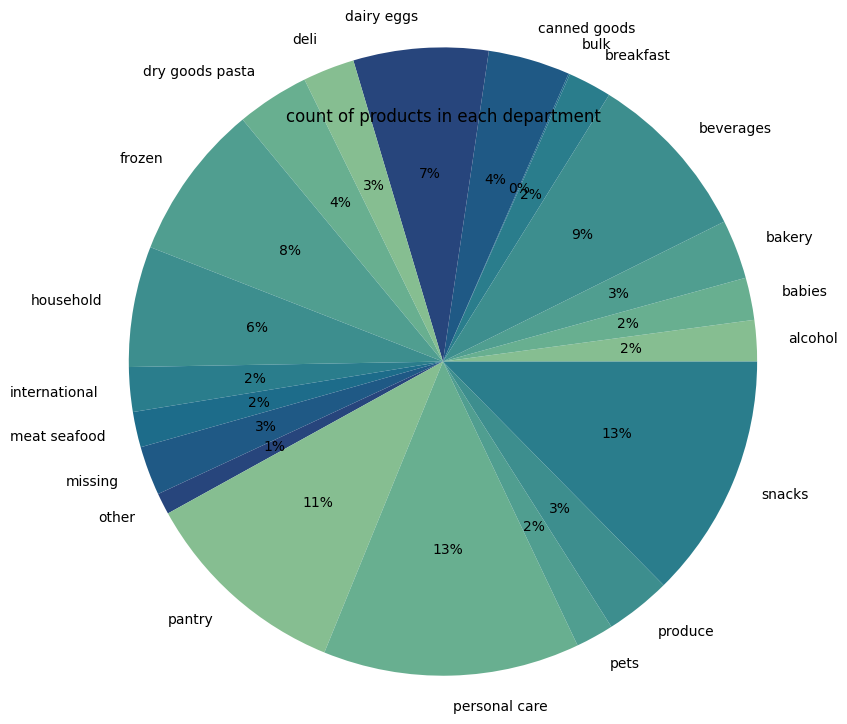

In [54]:
# count of products in each department

# merge products with departments
prod_dept = products.merge(departments, on='department_id', how='left')
data = prod_dept.groupby(['department']).agg({'product_id':'count'}).reset_index().rename(columns={'product_id':'products_count'})
plt.pie(data['products_count'], labels = data['department'], colors = colors, autopct='%.0f%%', radius=1.7)
plt.title('count of products in each department')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_29656\259823716.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupeddf = order_products.groupby(['department'], as_index=False).count().rename(columns={'department_id':'count_of_ordered_prods'})


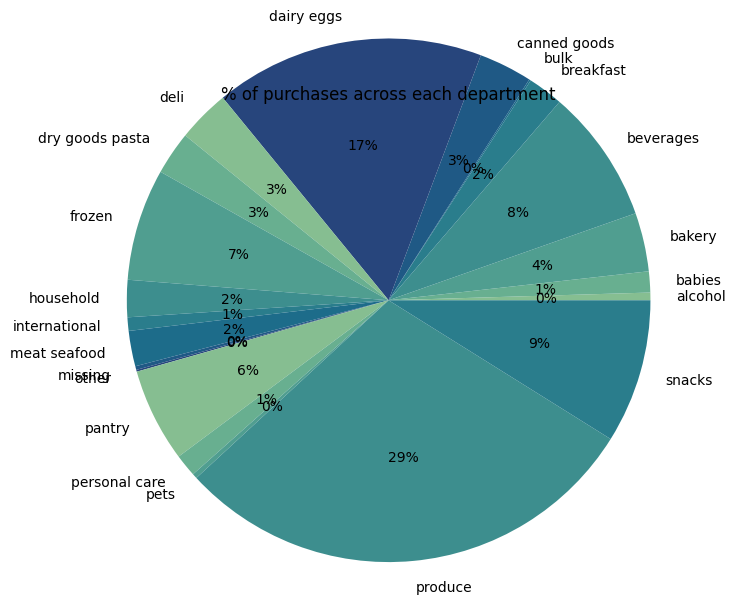

In [55]:
# From All ordered products, the count of contribution of each department
# Group by the count of ordering from a department
total_ordered_products = order_products.shape[0]
groupeddf = order_products.groupby(['department'], as_index=False).count().rename(columns={'department_id':'count_of_ordered_prods'})

fig = plt.figure(figsize = (20, 5))
plt.pie(groupeddf['count_of_ordered_prods'], labels = groupeddf['department'], colors = colors, autopct='%.0f%%', radius=1.7)
plt.title('% of purchases across each department')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_29656\3507211970.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupeddf = order_products.groupby(['aisle'], as_index=False).agg({'aisle_id':'count'}).rename(columns={'aisle_id':'count_of_ordered_prods'})


<Figure size 2000x500 with 0 Axes>

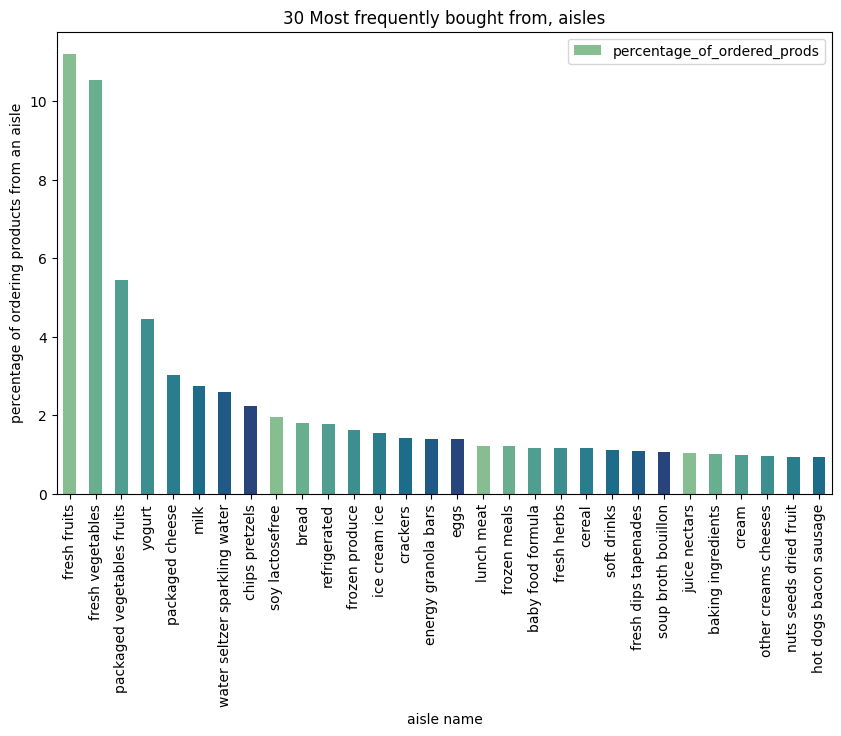

In [56]:
# From All ordered products, the count of contribution of each aisle
# Group by the count of ordering from an aisle
total_ordered_products = order_products.shape[0]
groupeddf = order_products.groupby(['aisle'], as_index=False).agg({'aisle_id':'count'}).rename(columns={'aisle_id':'count_of_ordered_prods'})
groupeddf['percentage_of_ordered_prods'] = groupeddf['count_of_ordered_prods']/total_ordered_products*100
groupeddf = groupeddf.sort_values(by=['count_of_ordered_prods'], ascending=False)
fig = plt.figure(figsize = (20, 5))
groupeddf.iloc[:30].plot.bar(x='aisle', y='percentage_of_ordered_prods', color=colors)
plt.ylabel('percentage of ordering products from an aisle')
plt.xlabel('aisle name')
plt.xticks(rotation=90)
plt.title('30 Most frequently bought from, aisles')
plt.show()

### Ratio de reorden por departamento

C:\Users\Admin\AppData\Local\Temp\ipykernel_29656\3248035255.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupeddf = order_products[non_first_orders].groupby(['department']).agg({'reordered':'mean'}).reset_index().rename(columns={'reordered':'reordered_ratio'})
C:\Users\Admin\AppData\Local\Temp\ipykernel_29656\3248035255.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='department', y='reordered_ratio', data=groupeddf, palette=colors)
C:\Users\Admin\AppData\Local\Temp\ipykernel_29656\3248035255.py:6: UserWarning: 
The palette list has fewer values (8) than needed (21) and will cycle, which may produce an uninterpretable plot.
  sns.barp

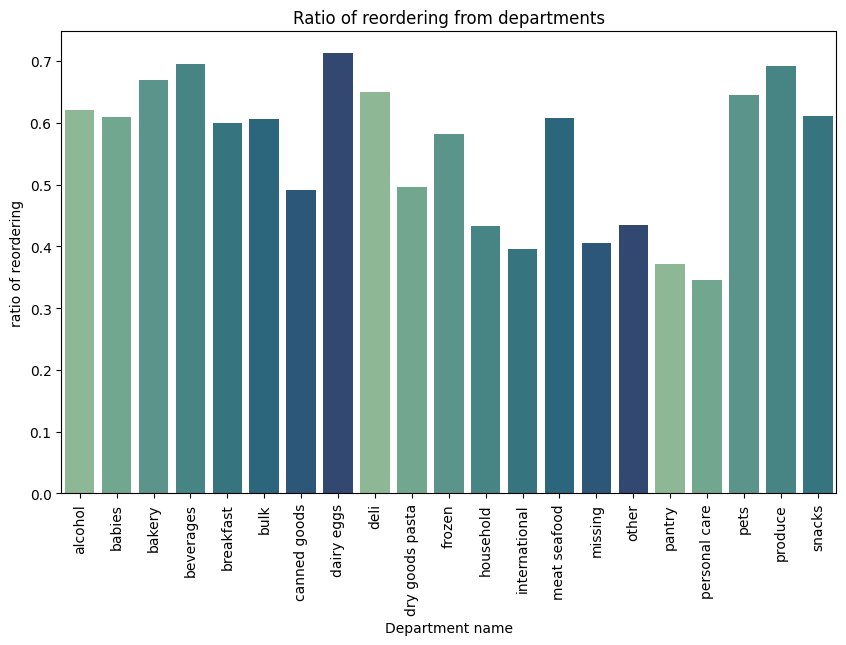

,department,reordered_ratio
7,dairy eggs,0.712287
3,beverages,0.695207
19,produce,0.691380
2,bakery,0.669671
8,deli,0.649702


In [57]:
# Heatmap on the propability of non-new users to reorder for each day each hour
non_first_orders = order_products['order_number'] != 1
groupeddf = order_products[non_first_orders].groupby(['department']).agg({'reordered':'mean'}).reset_index().rename(columns={'reordered':'reordered_ratio'})

groupeddf = groupeddf.sort_values(by=['reordered_ratio'], ascending=False)
sns.barplot(x='department', y='reordered_ratio', data=groupeddf, palette=colors)

plt.title('Ratio of reordering from departments')
plt.ylabel('ratio of reordering')
plt.xticks(rotation=90)
plt.xlabel('Department name')
plt.show()

groupeddf.head()

#### Revisión del departamento de bebidas alcoholicas

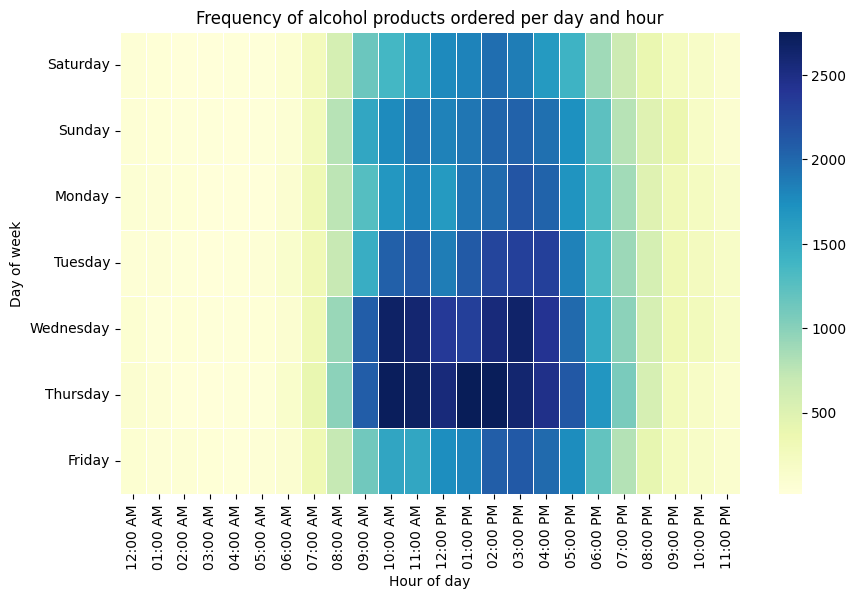

In [59]:
# dep_name = input('Enter the department name you want to generate heatmap for:')
dep_name = 'alcohol'
exists = dep_name in departments['department'].unique()

if exists:
    # Filtrar solo productos del departamento especificado
    dep_order_products = order_products[order_products['department'] == dep_name]

    # Agrupar por día y hora, contando cuántas veces aparece un producto
    groupeddf = dep_order_products.groupby(
        ['order_dow', 'order_hour_of_day'], observed=True
    )['order_id'].count().reset_index().rename(columns={'order_id': 'order_prods_count'})

    # Pivot para crear matriz de calor
    heatmap_data = groupeddf.pivot(
        index='order_dow',
        columns='order_hour_of_day',
        values='order_prods_count'
    )

    # Graficar heatmap
    ax = sns.heatmap(data=heatmap_data, cmap="YlGnBu", linewidths=0.5)
    plt.title(f'Frequency of {dep_name} products ordered per day and hour')
    plt.ylabel('Day of week')
    plt.xlabel('Hour of day')
    plt.show()
else:
    print(f"Department '{dep_name}' does not exist.")


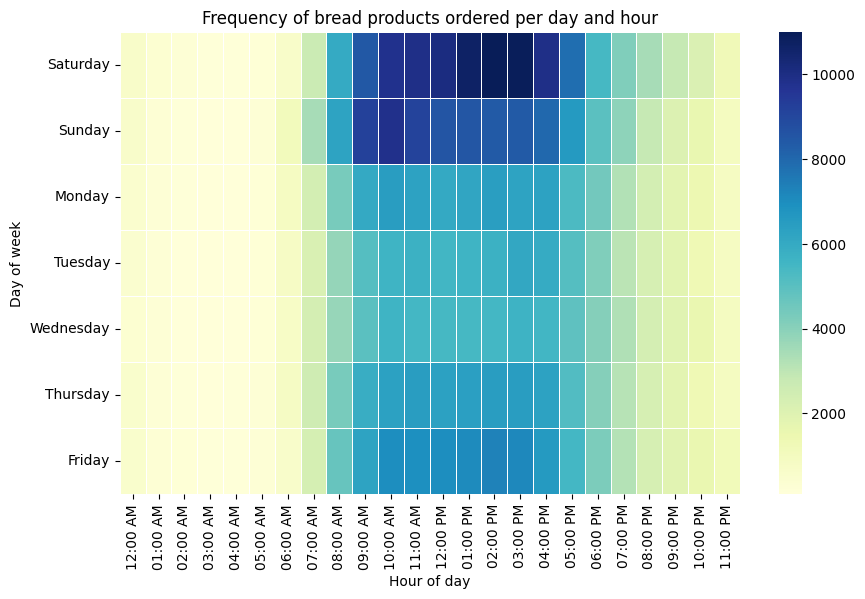

In [61]:
# aisle_name = input('Enter the aisle name you want to generate heatmap for:')
aisle_name = 'bread'
exists = aisle_name in aisles['aisle'].unique()

if exists:
    # Filtrar productos del pasillo especificado
    aisle_order_products = order_products[order_products['aisle'] == aisle_name]

    # Agrupar por día y hora, contando cuántas veces aparece un producto de ese pasillo
    groupeddf = aisle_order_products.groupby(
        ['order_dow', 'order_hour_of_day'], observed=True
    )['order_id'].count().reset_index().rename(columns={'order_id': 'order_prods_count'})

    # Pivot para construir la matriz del heatmap
    heatmap_data = groupeddf.pivot(
        index='order_dow',
        columns='order_hour_of_day',
        values='order_prods_count'
    )

    # Dibujar el heatmap
    ax = sns.heatmap(data=heatmap_data, cmap="YlGnBu", linewidths=0.5)
    plt.title(f'Frequency of {aisle_name} products ordered per day and hour')
    plt.ylabel('Day of week')
    plt.xlabel('Hour of day')
    plt.show()
else:
    print(f"Aisle '{aisle_name}' does not exist.")


In [62]:
order_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33819106 entries, 0 to 33819105
Data columns (total 16 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   order_id                int32   
 1   product_id              int32   
 2   add_to_cart_order       int16   
 3   reordered               int8    
 4   product_name            category
 5   aisle_id                int16   
 6   department_id           int8    
 7   is_organic              bool    
 8   user_id                 int32   
 9   eval_set                category
 10  order_number            int8    
 11  order_dow               category
 12  order_hour_of_day       category
 13  days_since_prior_order  float32 
 14  department              category
 15  aisle                   category
dtypes: bool(1), category(6), float32(1), int16(2), int32(3), int8(3)
memory usage: 1.1 GB


In [65]:
order_products.head(30)

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,is_organic,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,department,aisle
0,1,49302,1,1,Bulgarian Yogurt,120,16,False,112108,train,4,Wednesday,10:00 AM,9.0,dairy eggs,yogurt
1,1,11109,2,1,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,True,112108,train,4,Wednesday,10:00 AM,9.0,dairy eggs,other creams cheeses
2,1,10246,3,0,Organic Celery Hearts,83,4,True,112108,train,4,Wednesday,10:00 AM,9.0,produce,fresh vegetables
3,1,49683,4,0,Cucumber Kirby,83,4,False,112108,train,4,Wednesday,10:00 AM,9.0,produce,fresh vegetables
4,1,43633,5,1,Lightly Smoked Sardines in Olive Oil,95,15,False,112108,train,4,Wednesday,10:00 AM,9.0,canned goods,canned meat seafood
5,1,13176,6,0,Bag of Organic Bananas,24,4,True,112108,train,4,Wednesday,10:00 AM,9.0,produce,fresh fruits
6,1,47209,7,0,Organic Hass Avocado,24,4,True,112108,train,4,Wednesday,10:00 AM,9.0,produce,fresh fruits
7,1,22035,8,1,Organic Whole String Cheese,21,16,True,112108,train,4,Wednesday,10:00 AM,9.0,dairy eggs,packaged cheese
8,36,39612,1,0,Grated Pecorino Romano Cheese,2,16,False,79431,train,23,Friday,06:00 PM,30.0,dairy eggs,specialty cheeses
9,36,19660,2,1,Spring Water,115,7,False,79431,train,23,Friday,06:00 PM,30.0,beverages,water seltzer sparkling water


In [66]:
# Filtrar solo los productos que fueron los primeros añadidos al carrito en cada orden
first_product_per_order = order_products[order_products['add_to_cart_order'] == 1].copy()

# Asegurar que no haya duplicados accidentales
first_product_per_order = first_product_per_order.drop_duplicates(subset=['order_id'])

# Resetear índice por claridad
first_product_per_order.reset_index(drop=True, inplace=True)

# Ver las primeras filas
display(first_product_per_order.head())


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,is_organic,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,department,aisle
0,1,49302,1,1,Bulgarian Yogurt,120,16,False,112108,train,4,Wednesday,10:00 AM,9.0,dairy eggs,yogurt
1,36,39612,1,0,Grated Pecorino Romano Cheese,2,16,False,79431,train,23,Friday,06:00 PM,30.0,dairy eggs,specialty cheeses
2,38,11913,1,0,Shelled Pistachios,117,19,False,42756,train,6,Friday,04:00 PM,24.0,snacks,nuts seeds dried fruit
3,96,20574,1,1,Roasted Turkey,96,20,False,17227,train,7,Friday,08:00 PM,30.0,deli,lunch meat
4,98,8859,1,1,Natural Spring Water,115,7,False,56463,train,41,Tuesday,08:00 AM,14.0,beverages,water seltzer sparkling water


In [67]:
# Establecer order_id y user_id como índices
first_product_per_order.set_index(['order_id', 'user_id'], inplace=True)

In [69]:
# Mostrar cuántos valores nulos hay por columna
missing_counts = first_product_per_order.isnull().sum()

# Mostrar porcentaje de completitud
completeness = 100 * (1 - missing_counts / len(first_product_per_order))

# Unir ambos en una tabla
completeness_report = pd.DataFrame({
    'missing_values': missing_counts,
    'completeness_%': completeness.round(2)
})

display(completeness_report)


,missing_values,completeness_%
product_id,0,100.00
add_to_cart_order,0,100.00
reordered,0,100.00
product_name,0,100.00
aisle_id,0,100.00
department_id,0,100.00
is_organic,0,100.00
eval_set,0,100.00
order_number,0,100.00
order_dow,0,100.00


In [71]:
# Calcular la moda (valor más frecuente) de la columna
mode_value = first_product_per_order['days_since_prior_order'].mode().iloc[0]

# Rellenar los valores nulos con la moda
first_product_per_order['days_since_prior_order'] = first_product_per_order['days_since_prior_order'].fillna(mode_value)


In [72]:
# Mostrar cuántos valores nulos hay por columna
missing_counts = first_product_per_order.isnull().sum()

# Mostrar porcentaje de completitud
completeness = 100 * (1 - missing_counts / len(first_product_per_order))

# Unir ambos en una tabla
completeness_report = pd.DataFrame({
    'missing_values': missing_counts,
    'completeness_%': completeness.round(2)
})

display(completeness_report)


,missing_values,completeness_%
product_id,0,100.0
add_to_cart_order,0,100.0
reordered,0,100.0
product_name,0,100.0
aisle_id,0,100.0
department_id,0,100.0
is_organic,0,100.0
eval_set,0,100.0
order_number,0,100.0
order_dow,0,100.0


In [73]:
first_product_per_order.drop(columns=['order_number'], inplace=True)

In [76]:
first_product_per_order['product_id'] = first_product_per_order['product_id'].astype('category')
first_product_per_order['aisle_id'] = first_product_per_order['aisle_id'].astype('category')
first_product_per_order['department_id'] = first_product_per_order['department_id'].astype('category')

In [77]:
first_product_per_order.dtypes

product_id                category
add_to_cart_order            int16
reordered                     int8
product_name              category
aisle_id                  category
department_id             category
is_organic                    bool
eval_set                  category
order_dow                 category
order_hour_of_day         category
days_since_prior_order     float32
department                category
aisle                     category
dtype: object

In [78]:
variances = first_product_per_order.var(numeric_only=True)
display(variances)

add_to_cart_order          0.000000
reordered                  0.217851
is_organic                 0.209363
days_since_prior_order    99.011108
dtype: float64

In [79]:
first_product_per_order.drop(columns=['add_to_cart_order'], inplace=True)

In [80]:
first_product_per_order.dtypes

product_id                category
reordered                     int8
product_name              category
aisle_id                  category
department_id             category
is_organic                    bool
eval_set                  category
order_dow                 category
order_hour_of_day         category
days_since_prior_order     float32
department                category
aisle                     category
dtype: object

In [81]:
first_product_per_order['is_organic'] = first_product_per_order['is_organic'].astype('int8')

In [82]:
bins = [-1, 3, 7, 14, 30]
labels = ['very_recent', 'recent', 'medium', 'long']
first_product_per_order['days_since_prior_bucket'] = pd.cut(
    first_product_per_order['days_since_prior_order'], bins=bins, labels=labels
)

In [83]:
first_product_per_order.dtypes

product_id                 category
reordered                      int8
product_name               category
aisle_id                   category
department_id              category
is_organic                     int8
eval_set                   category
order_dow                  category
order_hour_of_day          category
days_since_prior_order      float32
department                 category
aisle                      category
days_since_prior_bucket    category
dtype: object

In [84]:
from sklearn.preprocessing import StandardScaler

# Crear el scaler
scaler = StandardScaler()

# Escalar la columna (y opcionalmente agregar una nueva columna escalada)
first_product_per_order['days_since_prior_order_scaled'] = scaler.fit_transform(
    first_product_per_order[['days_since_prior_order']]
)


In [85]:
# Asegurarnos de que los índices no se tomen como columnas
categorical_cols = first_product_per_order.select_dtypes(include=['category', 'object']).columns

# Excluir columnas del índice
categorical_cols = [col for col in categorical_cols if col not in first_product_per_order.index.names]


In [87]:
# Identificar columnas categóricas (ya lo tenías)
categorical_cols = first_product_per_order.select_dtypes(include=['category', 'object']).columns
categorical_cols = [col for col in categorical_cols if col not in first_product_per_order.index.names]

# Filtrar solo las que tienen <= 100 categorías únicas
low_cardinality_cols = [col for col in categorical_cols if first_product_per_order[col].nunique() <= 100]

# Aplicar OneHotEncoding solo a esas
first_product_per_order_encoded = pd.get_dummies(
    first_product_per_order,
    columns=low_cardinality_cols,
    drop_first=True
)


In [88]:
from sklearn.preprocessing import LabelEncoder

high_cardinality_cols = [col for col in categorical_cols if col not in low_cardinality_cols]

for col in high_cardinality_cols:
    le = LabelEncoder()
    first_product_per_order_encoded[col] = le.fit_transform(first_product_per_order[col])


In [89]:
first_product_per_order_encoded

,,product_id,reordered,product_name,aisle_id,is_organic,days_since_prior_order,aisle,days_since_prior_order_scaled,department_id_2,department_id_3,...,department_missing,department_other,department_pantry,department_personal care,department_pets,department_produce,department_snacks,days_since_prior_bucket_recent,days_since_prior_bucket_medium,days_since_prior_bucket_long
order_id,user_id,,,,,,,,,,,,,,,,,,,,,
1,112108,41873,1,4934,119,0,9.0,133,-0.316057,False,False,...,False,False,False,False,False,False,False,False,True,False
36,79431,33601,0,15549,1,0,30.0,120,1.794404,False,False,...,False,False,False,False,False,False,False,False,False,True
38,42756,10068,0,34098,116,0,24.0,88,1.191415,False,False,...,False,False,False,False,False,False,True,False,False,True
96,17227,17414,1,32799,95,0,30.0,80,1.794404,False,False,...,False,False,False,False,False,False,False,False,False,True
98,56463,7501,1,22858,114,0,14.0,131,0.186433,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3421079,108687,25563,0,22028,24,0,0.0,116,-1.220541,False,False,...,False,False,False,True,False,False,False,False,False,False
3421080,52726,23620,1,27598,83,1,2.0,83,-1.019545,False,False,...,False,False,False,False,False,False,False,False,False,False
3421081,117076,32407,0,16825,106,0,30.0,25,1.794404,False,False,...,False,False,False,False,False,False,True,False,False,True
